In [151]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from scipy import stats

In [153]:
df = pd.read_csv('churn_data.csv')

In [155]:
print("Data Overview:\n")
print(df.info())
print("\nFirst few rows:\n", df.head())
print("\nMissing Values:\n", df.isnull().sum())

Data Overview:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non

In [157]:
print("\nSummary Statistics:\n", df.describe())


Summary Statistics:
        SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


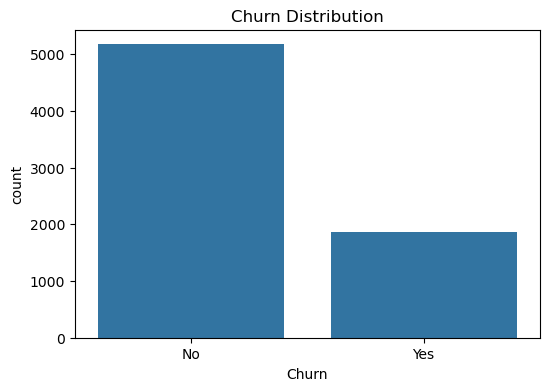

In [159]:
# Churn Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

In [128]:
# Correlation heatmap for numerical features
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

ValueError: could not convert string to float: '7590-VHVEG'

<Figure size 1000x800 with 0 Axes>

In [161]:
# Handle missing values (if any) - Imputation, drop rows, or other strategies
df = df.dropna()  # Example: Dropping rows with missing values

In [163]:
# Encoding categorical features
label_encoders = {}
for column in df.select_dtypes(include=['object']).columns:
    if column != 'Churn':  # Assuming 'Churn' is the target variable
        le = LabelEncoder()
        df[column] = le.fit_transform(df[column])
        label_encoders[column] = le

In [165]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [167]:
# Splitting data into train and test sets
X = df.drop('Churn', axis=1)
y = df['Churn']

In [169]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [171]:
model_params = {
    "Logistic Regression": {
        'model': LogisticRegression(random_state=42, max_iter=1000),
        'params': {
            'C': stats.loguniform(0.001, 10),
            'solver': ['lbfgs', 'liblinear']
        }
    },
    "Linear SVM": {
        'model': LinearSVC(random_state=42, max_iter=10000),
        'params': {
            'C': stats.loguniform(0.001, 10)
        }
    },
    "Support Vector Machine (RBF Kernel)": {
        'model': SVC(probability=True, random_state=42),
        'params': {
            'C': stats.loguniform(0.001, 10),
            'gamma': stats.loguniform(0.001, 1)
        }
    },
    "K-Nearest Neighbors": {
        'model': KNeighborsClassifier(),
        'params': {
            'n_neighbors': [3, 5, 7, 9],
            'weights': ['uniform', 'distance'],
            'metric': ['euclidean', 'manhattan']
        }
    },
    "Random Forest": {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [50, 100, 200],
            'max_depth': [None, 10, 20, 30],
            'min_samples_split': [2, 5, 10]
        }
    },
    "Gradient Boosting": {
        'model': GradientBoostingClassifier(random_state=42),
        'params': {
            'n_estimators': [50, 100, 200],
            'learning_rate': [0.01, 0.1, 0.2],
            'max_depth': [3, 5, 7]
        }
    }
}

In [173]:
stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
repeated_stratified_kfold = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)

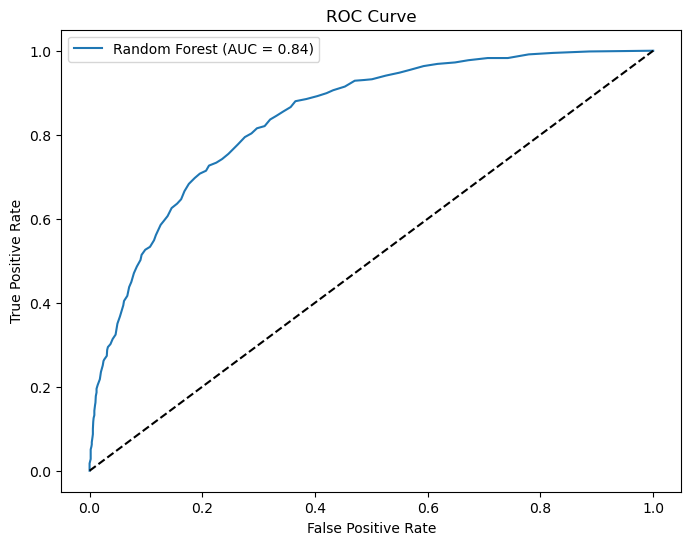

In [175]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='Random Forest (AUC = {:.2f})'.format(roc_auc_score(y_test, y_pred_proba)))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [177]:
# Dictionary to store the best model and its metrics
best_models = {
    "Model": [],
    "Best Parameters": [],
    "Accuracy (CV)": [],
    "Precision (CV)": [],
    "Recall (CV)": [],
    "F1 Score (CV)": [],
    "ROC AUC (CV)": []
}

In [179]:
for model_name, mp in model_params.items():
    print(f"\nRandomized Search on {model_name}...")
    randomized_search = RandomizedSearchCV(
        mp['model'], 
        mp['params'], 
        cv=stratified_kfold, 
        scoring='roc_auc', 
        n_iter=20,  # Limit number of parameter settings sampled
        n_jobs=-1,  # Use all available cores
        random_state=42
    )
    randomized_search.fit(X, y)
    
    # Extract the best model and parameters
    best_model = randomized_search.best_estimator_
    best_params = randomized_search.best_params_
    print(f"Best parameters for {model_name}: {best_params}")
    
    # Cross-validation with the best model for more metrics
    accuracy = cross_val_score(best_model, X, y, cv=stratified_kfold, scoring='accuracy').mean()
    precision = cross_val_score(best_model, X, y, cv=stratified_kfold, scoring='precision').mean()
    recall = cross_val_score(best_model, X, y, cv=stratified_kfold, scoring='recall').mean()
    f1 = cross_val_score(best_model, X, y, cv=stratified_kfold, scoring='f1').mean()
    roc_auc = cross_val_score(best_model, X, y, cv=stratified_kfold, scoring='roc_auc').mean()
    
    # Append the results
    best_models["Model"].append(model_name)
    best_models["Best Parameters"].append(best_params)
    best_models["Accuracy (CV)"].append(accuracy)
    best_models["Precision (CV)"].append(precision)
    best_models["Recall (CV)"].append(recall)
    best_models["F1 Score (CV)"].append(f1)
    best_models["ROC AUC (CV)"].append(roc_auc)


Randomized Search on Logistic Regression...
Best parameters for Logistic Regression: {'C': 0.12563152773938666, 'solver': 'lbfgs'}

Randomized Search on Linear SVM...
Best parameters for Linear SVM: {'C': 0.016480446427978974}

Randomized Search on Support Vector Machine (RBF Kernel)...
Best parameters for Support Vector Machine (RBF Kernel): {'C': 2.1368329072358767, 'gamma': 0.004335281794951566}

Randomized Search on K-Nearest Neighbors...


C:\Users\Osama\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 16 is smaller than n_iter=20. Running 16 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best parameters for K-Nearest Neighbors: {'weights': 'uniform', 'n_neighbors': 9, 'metric': 'manhattan'}

Randomized Search on Random Forest...
Best parameters for Random Forest: {'n_estimators': 200, 'min_samples_split': 10, 'max_depth': 10}

Randomized Search on Gradient Boosting...
Best parameters for Gradient Boosting: {'n_estimators': 50, 'max_depth': 3, 'learning_rate': 0.1}

Best Model Comparison after Hyperparameter Tuning:
                                  Model  \
0                  Logistic Regression   
1                           Linear SVM   
2  Support Vector Machine (RBF Kernel)   
3                  K-Nearest Neighbors   
4                        Random Forest   
5                    Gradient Boosting   

                                     Best Parameters  Accuracy (CV)  \
0      {'C': 0.12563152773938666, 'solver': 'lbfgs'}       0.803205   
1                        {'C': 0.016480446427978974}       0.803347   
2  {'C': 2.1368329072358767, 'gamma': 0.004335281...   

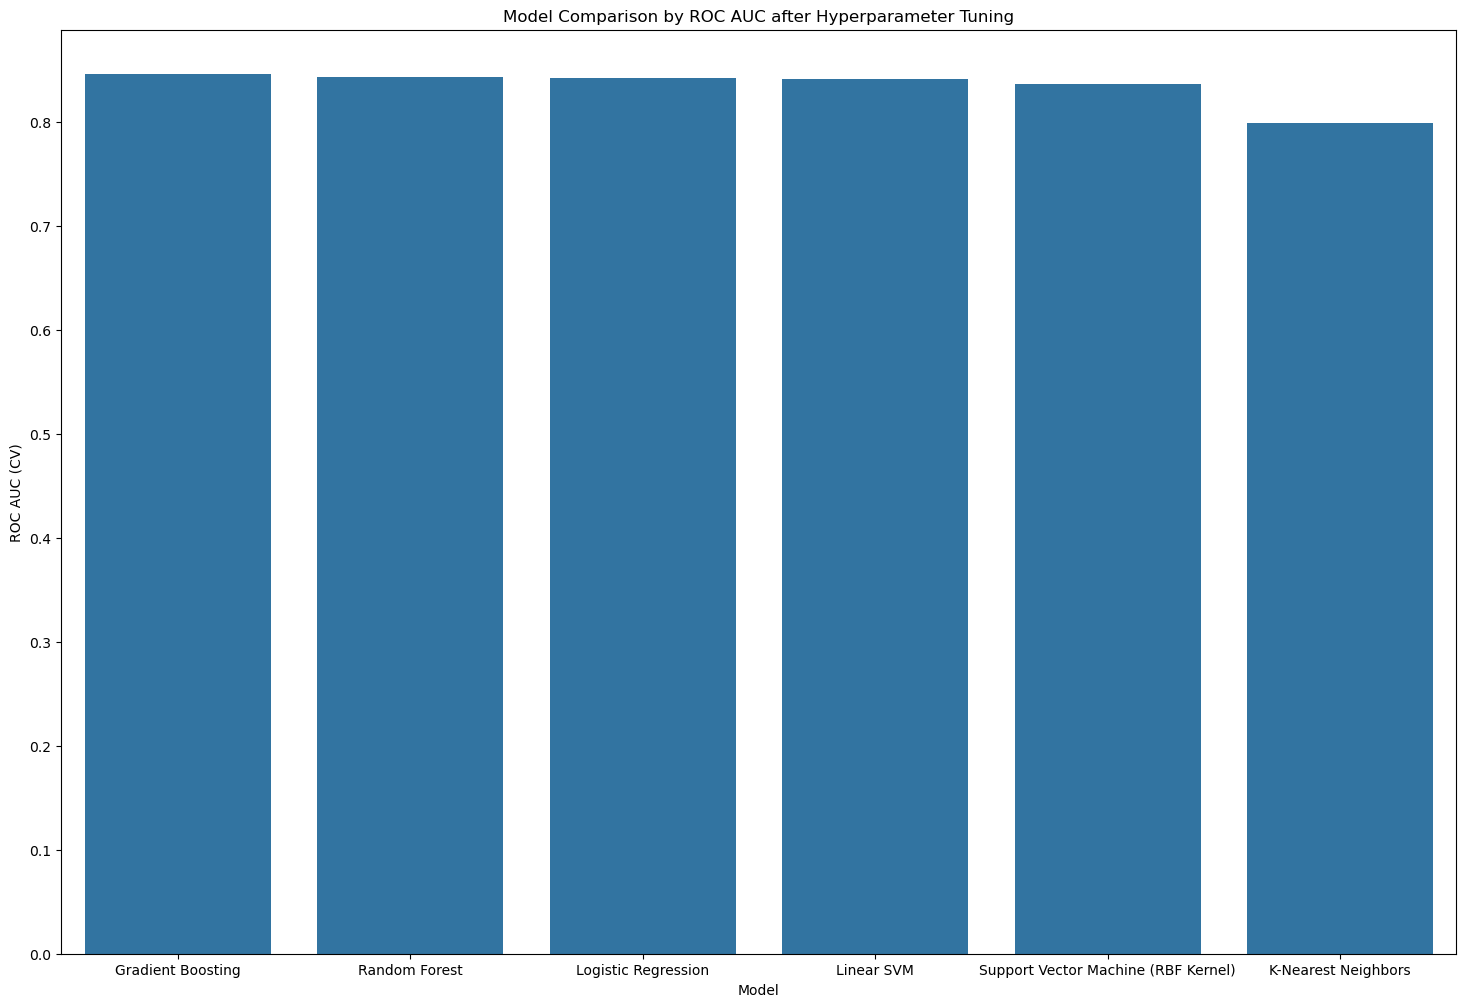

In [187]:
# Visualization of ROC AUC for tuned models
plt.figure(figsize=(18, 12))
sns.barplot(x='Model', y='ROC AUC (CV)', data=best_models_df.sort_values(by='ROC AUC (CV)', ascending=False))
plt.title("Model Comparison by ROC AUC after Hyperparameter Tuning")
plt.show()